> **Note.** This is a copy of `healthcare-thesis/notebooks/02_c2_text_controls.ipynb`, placed here so the
> whole notebook set sits beside the presentation. The path bootstrap below finds the
> source folder automatically, so it runs from either location.


# 02 · C2 — the first controls that read text

C0 predicted the same codes for everything. C1 copied its nearest neighbour's codes. Neither
reads any text beyond a name.

C2 does read text — the analyst's intervention name and summary, not the PDF. Two variants:

| | |
|---|---|
| **C2a** | TF-IDF character n-grams + one-vs-rest logistic regression. Runs anywhere, no GPU. |
| **C2b** | SetFit — contrastive fine-tuning of a multilingual sentence transformer, then a one-vs-rest head. Built for the tens-of-examples regime. GPU. |

Why this matters: if a plain logistic regression over a two-sentence summary beats a
retrieval-augmented language model reading the whole document, that is the result — and it sets
the bar the proposed system has to clear.

Scored by 5-fold cross-validation over all 91 document-backed interventions, so every
intervention is tested exactly once.

In [1]:
import sys, pathlib
# find healthcare-thesis/src no matter which folder this notebook is opened from
root = pathlib.Path.cwd()
for _ in range(5):
    if (root / "healthcare-thesis" / "src").exists():
        break
    root = root.parent
SRC = root / "healthcare-thesis" / "src"
sys.path.insert(0, str(SRC))
import warnings; warnings.filterwarnings("ignore")
import config, eric, gold, evaluation, baselines, classifiers, shortlist
import pandas as pd, numpy as np
rows, _ = gold.load_all(save=False)
print(f"{len(rows)} interventions, {sum(r.has_pdf for r in rows)} with a PDF")

126 interventions, 91 with a PDF


## 1 · C2a — linear one-vs-rest

Sweep the decision threshold and the input field. The threshold is doing real work here: it sets how many codes the model emits, and the gold sets average about 10.

In [2]:
res = []
for field in ("name", "name+summary"):
    for thr in (0.25, 0.30, 0.35, 0.40, 0.45, 0.50):
        r = evaluation.cross_validate(rows, lambda f=field, t=thr:
                                      classifiers.LinearMultiLabel(field=f, threshold=t))
        p = r["pooled"]
        res.append({"field": field, "thr": thr, "F1": p.f1 * 100,
                    "P": p.precision * 100, "R": p.recall * 100,
                    "cat_F1": evaluation.category_f1(r["preds"], r["golds"]).f1 * 100,
                    "fold_min": r["fold_min"] * 100, "fold_max": r["fold_max"] * 100})
c2a = pd.DataFrame(res).round(1)
c2a.sort_values("F1", ascending=False).head(8)

,field,thr,F1,P,R,cat_F1,fold_min,fold_max
9,name+summary,0.4,52.2,45.7,60.7,81.2,38.2,61.9
10,name+summary,0.4,51.6,51.4,51.8,78.6,41.0,60.3
8,name+summary,0.4,51.0,40.3,69.5,82.1,37.1,61.1
4,name,0.4,49.4,43.6,56.9,81.2,31.8,59.3
5,name,0.5,49.3,47.4,51.5,80.1,30.0,58.9
3,name,0.4,48.9,40.4,62.0,81.5,31.6,58.6
7,name+summary,0.3,48.6,35.3,77.7,82.0,35.0,58.2
2,name,0.4,48.3,37.4,68.1,81.4,33.6,57.6


### Against the earlier controls

In [3]:
best = c2a.sort_values("F1", ascending=False).iloc[0]
ladder = []
for name, factory in [
    ("C0  frequency prior (k=18)", lambda: baselines.PriorBaseline(18)),
    ("C1  kNN name",               lambda: baselines.KNNBaseline(k=3, threshold=0.5, field="name")),
    ("C1  kNN name+summary",       lambda: baselines.KNNBaseline(k=3, threshold=0.5, field="name+summary")),
    ("C2a linear one-vs-rest",     lambda: classifiers.LinearMultiLabel(field=best.field, threshold=float(best.thr))),
]:
    r = evaluation.cross_validate(rows, factory)
    p = r["pooled"]
    ladder.append({"control": name, "F1": p.f1 * 100, "P": p.precision * 100, "R": p.recall * 100,
                   "category_F1": evaluation.category_f1(r["preds"], r["golds"]).f1 * 100,
                   "fold_range": f"{r['fold_min']*100:.0f}-{r['fold_max']*100:.0f}"})
    if name.startswith("C0"):
        preds_c0 = r["preds"]; golds_all = r["golds"]
    if name.startswith("C2a"):
        preds_c2a = r["preds"]
pd.DataFrame(ladder).round(1)

,control,F1,P,R,category_F1,fold_range
0,C0 frequency prior (k=18),44.2,35.7,58.0,80.9,38-50
1,C1 kNN name,45.6,51.8,40.7,75.4,27-55
2,C1 kNN name+summary,49.1,49.7,48.5,76.4,36-53
3,C2a linear one-vs-rest,52.2,45.7,60.7,81.2,38-62


For reference, the earlier four-stage pipeline scored **39.2** on ERIC codes while reading the documents. Every control here is measured on a different corpus split, so this is an indication rather than a like-for-like comparison — but the ordering is the point.

In [4]:
cmp = evaluation.paired_bootstrap(preds_c0, preds_c2a, golds_all)
print(f"P(C2a better than C0) = {cmp['p_b_better']:.3f}")
print(f"median delta F1 = {cmp['median_delta']*100:+.1f}  "
      f"(95% CI {cmp['ci95'][0]*100:+.1f} to {cmp['ci95'][1]*100:+.1f})")

P(C2a better than C0) = 1.000
median delta F1 = +7.8  (95% CI +4.3 to +11.5)


## 2 · C2b — SetFit

Runs only where `setfit` is installed (DGX). On CPU this cell reports that it was skipped rather
than failing, so the notebook stays runnable everywhere.

    pip install torch sentence-transformers setfit

In [5]:
if classifiers.SetFitMultiLabel.available():
    r = evaluation.cross_validate(rows, lambda: classifiers.SetFitMultiLabel(), n_folds=5)
    print("C2b SetFit:", r["pooled"])
    print("  category:", evaluation.category_f1(r["preds"], r["golds"]))
else:
    print("SKIPPED — setfit not installed. Run this notebook on the DGX to fill in C2b.")

SKIPPED — setfit not installed. Run this notebook on the DGX to fill in C2b.


## 3 · Where the errors are

Per-category recall for the best control. The categories a text-only method cannot recover are the ones a document-reading system has to earn its keep on.

In [6]:
from collections import Counter
hit, tot = Counter(), Counter()
for p, g in zip(preds_c2a, golds_all):
    for code in g:
        cat = eric.strategy_to_category()[code]
        tot[cat] += 1
        hit[cat] += code in set(p)
per_cat = pd.DataFrame([{"category": c, "gold": tot[c], "recovered": hit[c],
                         "recall": round(100 * hit[c] / tot[c], 1)} for c in tot]
                       ).sort_values("recall")
per_cat

,category,gold,recovered,recall
7,Utilize financial strategies,30,5,16.7
5,Support clinicians,82,38,46.3
3,Change infrastructure,127,61,48.0
4,Provide interactive assistance,99,57,57.6
1,Develop stakeholder interrelationships,149,91,61.1
8,Engage consumers,90,55,61.1
6,Use evaluative and iterative strategies,165,111,67.3
0,Train and educate stakeholders,147,103,70.1
2,Adapt and tailor to context,119,91,76.5


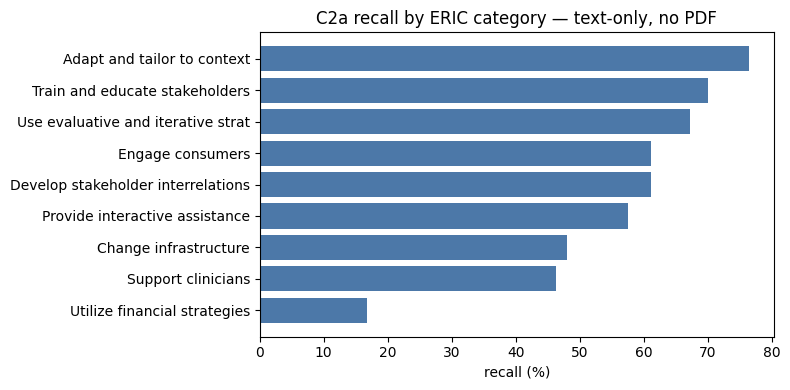

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([c[:34] for c in per_cat.category], per_cat.recall, color="#4C78A8")
ax.set_xlabel("recall (%)"); ax.set_title("C2a recall by ERIC category — text-only, no PDF")
plt.tight_layout(); plt.savefig(config.OUTPUTS / "fig_02_c2_by_category.png", dpi=150); plt.show()

## Reading

Write the conclusion here before moving on: which categories are already solved without reading a
document, and which are not. The second list is the target for the per-label verdict stage.